In [1]:
# Importation des packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [5]:
# Importation des données
df = pd.read_excel('data/data.xlsx', header=1)

In [6]:
# Renommer les variables 
df = df.rename(columns={
    'Date operation': 'DATE_OPERATION', 
    'Montant': 'MONTANT', 
    'Duree': 'DUREE', 
    'PRIOD': 'PERIODE',
    'Taux %': 'TAUX_INT',
    'NBRE ECH': 'NB_ECH',
    'SEX': 'SEXE'})

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
df = df[(df['VALEURGARANT'].notna()) & (df['PORTEF'] != 'FSE') & (df['SEXE'].notna())]

In [9]:
df.shape

(927, 21)

In [10]:
df['INDLIB'].unique()

<StringArray>
['H�tel, Caf�, Retaurant, Spectacl',                    'Autre Service',
               'Industrie de P�che',                 'Commerce G�n�ral',
                                nan,      'B�timent et Travaux Publics',
      'Elevage, Production Animale',                           'Divers',
              'Production Agricole',                       'Transports',
            'Industrie Alimentaire', 'Indus. M�taux, Const M�ca & El�c',
  'Commerce V�hicules & Pi�ces D�t',  'Indus. Text Cuir et Habillement',
                   'Autre Commerce',  'Commerce Sp�cialis� Alimentaire',
 'Commerce Mat.1�re, Const, Quinca', 'Industrie Materiaux Construction',
  'Transit Manut, Auxiliare Transp',    'Industrie Bois et Ameublement',
  'Production et Distrib Eau/El�ct']
Length: 21, dtype: str

In [11]:
corrections = {
    'H�tel, Caf�, Retaurant, Spectacl': 'Hôtel, Café, Restaurant, Spectacle',
    'Industrie de P�che': 'Industrie de Pêche',
    'Commerce G�n�ral': 'Commerce Général',
    'B�timent et Travaux Publics': 'Bâtiment et Travaux Publics',
    'Elevage, Production Animale': 'Élevage, Production Animale',
    'Indus. M�taux, Const M�ca & El�c': 'Industrie Métaux, Construction Mécanique & Électrique',
    'Commerce V�hicules & Pi�ces D�t': 'Commerce Véhicules & Pièces Détachées',
    'Indus. Text Cuir et Habillement': 'Industrie Textile, Cuir et Habillement',
    'Commerce Sp�cialis� Alimentaire': 'Commerce Spécialisé Alimentaire',
    'Commerce Mat.1�re, Const, Quinca': 'Commerce Matières Premières, Construction, Quincaillerie',
    'Industrie Materiaux Construction': 'Industrie Matériaux Construction',
    'Transit Manut, Auxiliare Transp': 'Transit, Manutention, Auxiliaire Transport',
    'Production et Distrib Eau/El�ct': 'Production et Distribution Eau/Électricité'
}

df['INDLIB'] = df['INDLIB'].replace(corrections)

In [12]:
# Exporter les données 
df.to_excel('data/working_dataset.xlsx', index=False)

In [13]:
# Importation des données 
df = pd.read_excel('data/working_dataset.xlsx')

In [14]:
df.shape

(927, 21)

# Netoyage des données

### DATE_OPERATION

In [13]:
df['DATE_OPERATION'] = pd.to_datetime(
    df['DATE_OPERATION'],
    format='%d-%b-%y',
    errors='coerce'
)

### INDLIB & IND

In [14]:
round(df['INDLIB'].value_counts(normalize=True) * 100, 2)

INDLIB
Commerce Général                                            66.45
Autre Service                                                8.83
Autre Commerce                                               7.17
Bâtiment et Travaux Publics                                  2.87
Industrie de Pêche                                           2.43
Divers                                                       2.43
Hôtel, Café, Restaurant, Spectacle                           2.10
Production Agricole                                          1.77
Élevage, Production Animale                                  0.99
Industrie Textile, Cuir et Habillement                       0.99
Transports                                                   0.88
Commerce Véhicules & Pièces Détachées                        0.88
Industrie Alimentaire                                        0.44
Commerce Spécialisé Alimentaire                              0.44
Industrie Métaux, Construction Mécanique & Électrique        0.33
Ind

In [15]:
# Pourcentage des valeurs manquantes
print(f"Valeurs manquantes: {df['INDLIB'].isnull().sum()}/{df.shape[0]} ({round((df['INDLIB'].isnull().sum() / df.shape[0]) * 100, 2)}%)")

Valeurs manquantes: 21/927 (2.27%)


In [15]:
# Remplacer les valeurs manquantes 
df['IND'] = df['IND'].fillna(0)
df['INDLIB'] = df['INDLIB'].fillna('Inconnu')

In [16]:
df['INDLIB'].value_counts(normalize=True)

INDLIB
Commerce Général                                            0.649407
Autre Service                                               0.086300
Autre Commerce                                              0.070119
Bâtiment et Travaux Publics                                 0.028047
Industrie de Pêche                                          0.023732
Divers                                                      0.023732
Inconnu                                                     0.022654
Hôtel, Café, Restaurant, Spectacle                          0.020496
Production Agricole                                         0.017260
Élevage, Production Animale                                 0.009709
Industrie Textile, Cuir et Habillement                      0.009709
Transports                                                  0.008630
Commerce Véhicules & Pièces Détachées                       0.008630
Industrie Alimentaire                                       0.004315
Commerce Spécialisé Aliment

In [17]:
secteur_mapping = {
    # Primaire
    'Production Agricole': 'Primaire',
    'Élevage, Production Animale': 'Primaire',
    'Industrie de Pêche': 'Primaire',

    # Secondaire
    'Industrie Alimentaire': 'Secondaire',
    'Industrie Métaux, Construction Mécanique & Électrique': 'Secondaire',
    'Industrie Textile, Cuir et Habillement': 'Secondaire',
    'Industrie Matériaux Construction': 'Secondaire',
    'Industrie Bois et Ameublement': 'Secondaire',
    'Bâtiment et Travaux Publics': 'Secondaire',
    'Production et Distribution Eau/Électricité': 'Secondaire',

    # Tertiaire
    'Hôtel, Café, Restaurant, Spectacle': 'Tertiaire',
    'Autre Service': 'Tertiaire',
    'Commerce Général': 'Tertiaire',
    'Commerce Véhicules & Pièces Détachées': 'Tertiaire',
    'Autre Commerce': 'Tertiaire',
    'Commerce Spécialisé Alimentaire': 'Tertiaire',
    'Commerce Matières Premières, Construction, Quincaillerie': 'Tertiaire',
    'Transports': 'Tertiaire',
    'Transit, Manutention, Auxiliaire Transport': 'Tertiaire',

    # Autres
    'Divers': 'No classé',
    'Inconnu': 'Inconnu'
}

In [18]:
# Position just after INDLIB
pos = df.columns.get_loc('INDLIB') + 1

# Create and insert the new variable
df.insert(pos, 'SECT_ECON', df['INDLIB'].map(secteur_mapping))

In [19]:
df['SECT_ECON'].value_counts(normalize=True)

SECT_ECON
Tertiaire     0.851133
Secondaire    0.051780
Primaire      0.050701
No classé     0.023732
Inconnu       0.022654
Name: proportion, dtype: float64

### MONTANT

<Axes: >

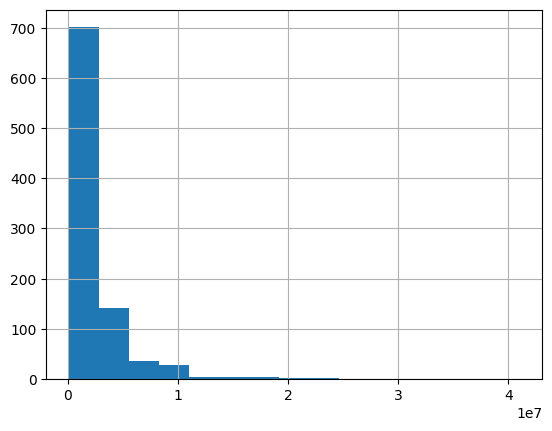

In [20]:
df['MONTANT'].hist(bins=15)

In [21]:
(df['MONTANT'] <= 0).sum()

np.int64(0)

### DATENAIS

In [23]:
def clean_birth_date(x):
    if pd.isna(x):
        return pd.NaT

    # If already datetime
    if isinstance(x, (pd.Timestamp, datetime)):
        date = pd.to_datetime(x)

    # If Excel serial number
    elif isinstance(x, (int, float)):
        date = pd.to_datetime(x, origin='1899-12-30', unit='D')

    # If text like 25-MAY-72
    else:
        date = pd.to_datetime(x, format='%d-%b-%y', errors='coerce')

    # Correct future birth dates caused by 2-digit year problem
    if pd.notna(date) and date.year > datetime.today().year:
        date = date - pd.DateOffset(years=100)

    return date

df['DATENAIS'] = df['DATENAIS'].apply(clean_birth_date)

In [24]:
# Convert DATENAIS to datetime
df['DATENAIS'] = pd.to_datetime(df['DATENAIS'], errors='coerce')

# Calculate age
today = pd.Timestamp.today()

age = (
    today.year 
    - df['DATENAIS'].dt.year 
    - (
        (today.month < df['DATENAIS'].dt.month) |
        ((today.month == df['DATENAIS'].dt.month) & (today.day < df['DATENAIS'].dt.day))
    )
)

# Remove AGE if it already exists
df = df.drop(columns=['AGE'], errors='ignore')

# Insert AGE directly after DATENAIS
pos = df.columns.get_loc('DATENAIS') + 1
df.insert(pos, 'AGE', age)

### DEPNAISLIB

In [25]:
df['WILAYA_NAISSANCE'] = (
    df['DEPNAISLIB']
    .str.split(' - ')
    .str[0]
    .replace('Toute la Mauritanie', 'Inconnu')
    .fillna('Inconnu')
)

In [26]:
df['WILAYA_NAISSANCE'].value_counts(normalize=True).mul(100).round(2)

WILAYA_NAISSANCE
Inconnu             41.21
Nouakchott          21.25
Trarza               8.95
Assaba               5.39
Brakna               3.34
Hodh el Gharbi       3.24
Guidimakha           2.59
Adrar                2.48
Tagant               2.48
Gorgol               2.37
Hodh Ech Chargui     2.16
Nouadhibou           1.94
Inchiri              1.94
Tiris Zemmour        0.65
Name: proportion, dtype: float64

In [27]:
df.head(3)

,DATE_OPERATION,LIBELLE,ACT,IND,INDLIB,SECT_ECON,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEXE,VALEURGARANT,AGENCELIB,IMPAYE,NBIMP,MNTREMB,DATENAIS,AGE,ETATCIVIL,DEPNAISLIB,SECT_ACTIV,WILAYA_NAISSANCE
0,20-APR-17,CRDT LT- MOURABAHA FADES DD,DD,23.0,"Hôtel, Café, Restaurant, Spectacle",Tertiaire,DD,16000000.0,96,T,8.0,32,Female,26000000,NOUAKCHOTT 1 - SIEGE,0.0,0,788565.21,1966-07-14,59,Married,Toute la Mauritanie,AUTRES SOCIETES,Inconnu
1,19-FEB-13,CRDT MT- MOURABAHA FADES DC,DC,24.0,Autre Service,Tertiaire,DDC,1000000.0,48,M,8.0,48,Male,1089103,NOUAKCHOTT 1 - SIEGE,0.0,0,25608.95,1972-05-25,53,Married,Toute la Mauritanie,ENTREPRISES INDIVIDUELLES,Inconnu
2,21-FEB-13,CRDT MT- MOURABAHA FADES DC,DC,24.0,Autre Service,Tertiaire,DDC,300000.0,36,M,6.0,36,Female,1180000,NOUAKCHOTT 1 - SIEGE,0.0,0,9293.61,1966-12-30,59,Divorced,Toute la Mauritanie,ENTREPRISES INDIVIDUELLES,Inconnu


In [28]:
# Supprimer des variables insignificatifs
df.drop(columns=['LIBELLE', 'IND', 'INDLIB', 'DEPNAISLIB'], inplace=True)

In [30]:
df.shape

(927, 20)

In [29]:
# Exporter les données pour l'analyse
df.to_excel('data/clean_data.xlsx', index=False)

# Ingénerie des données

In [ ]:
df.insert(1, 'ANNEE_OPERATION', df['DATE_OPERATION'].dt.year)
df.insert(2, 'MOIS_OPERATION', df['DATE_OPERATION'].dt.month)
